In [1]:
import os, sys, re, random, json5
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, IterableDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2
import traceback


In [2]:
os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-vehicles\\experiments'

In [3]:
from classifier import *

In [4]:
class IMDataset(Dataset):
    available_categories = ('bus', 'car', 'motorcycle', 'truck')

    mappings = {
        "n02892201": ("bus", "bus, autobus, coach, charabanc, double-decker, jitney, motorcoach, omnibus"),
        "n04467665": ("truck", "trailer truck, tractor trailer, trucking rig, rig, articulated lorry, semi"),
        # "n04467332": ("truck", "pickup, pickup truck"),
        # "n08641617": ("truck", "tow truck, tow car, wrecker"),
        "n02958343": ("car", "car, auto, automobile, machine, motorcar"),
        # "n03100232": ("car", "convertible"),
        "n03594945": ("car", "jeep, landrover"),
        "n03769881": ("car", "minivan"),
        "n04037443": ("car", "racer, race car, racing car"),
        "n04285008": ("car", "sports car, sport car"),
        "n03790512": ("motorcycle", "motorcycle, motorbike"),
        "n02835271": ("motorcycle", "bicycle-built-to-two, tandem bicycle, tandem"),
    }

    reverse = {
        "bus": ["n02892201"],
        "truck": ["n04467665"],
        "car": ["n02958343", "n03594945", "n03769881", "n04037443", "n04285008"],
        "motorcycle": ["n03790512", "n02835271"],
    }

    @staticmethod
    def load_image(
            specimen: str = 'train',
            mapping: str = None,
            sample: str = None,
            root: str = '..',
            log: bool = False,
            descriptor=None,
            dtype=np.float32,
    ):
        try:
            if mapping is None: mapping = random.choice(list(IMDataset.mappings.keys()))
            if mapping not in IMDataset.mappings: mapping = random.choice(IMDataset.reverse[mapping])
            assert specimen in ('train', 'test', 'validation')
            assert mapping in IMDataset.mappings
            directory = os.path.join(root, 'dataset', 'imagenet', mapping)  # TODO: Add TTV splits
            if sample is None: sample = random.choice(os.listdir(directory)).rsplit('.', 1)[0]
            if log: print(f'Loading {specimen}/{mapping}/{sample}')
            image = Image.open(os.path.join(directory, f'{sample}.JPEG'))
            if image.mode != 'RGB': image = image.convert('RGB')
            image = np.array(image, dtype=dtype)
            if descriptor is not None: return descriptor, image
            box = (0.0, 0.0, image.shape[1], image.shape[0])
            return {'label': IMDataset.mappings[mapping][0], 'box': box, 'dir': (specimen, mapping, sample)}, image
        except Exception as e:
            print(f'Error loading {specimen}/{mapping}/{sample}')
            raise e

    @staticmethod
    def process_sample(descriptor, image):
        # descriptor, image = context_crop_sample(descriptor, image, ratio=0.6)
        descriptor, image = ensure_within(descriptor, image, max_bounds=224)
        descriptor, image = pad_up_sample(descriptor, image, sampling=224)
        # labels, samples, descriptors = split_sample(descriptor, image, sampling=32, return_boxes=return_boxes)
        labels = np.zeros((1, 4))
        labels[0, class_to_idx[descriptor['label']]] = 1
        return labels, [image], None, None, None


    def __init__(self, specimen='train', root='..', hard_limit=None, dtype=np.float32):
        assert specimen in ('train', 'test', 'validation')
        self.root = root
        self.directory = os.path.join(root, 'dataset', 'imagenet') # TODO add specimen
        mappings = os.listdir(self.directory)
        self.descriptors: list[Descriptor] = []
        for mapping in mappings:
            class_dir = os.path.join(self.directory, mapping)
            for sample in os.listdir(class_dir):
                descriptor: Descriptor = {'label': IMDataset.mappings[mapping][0], 'box': None, 'dir': (specimen, mapping, sample.rsplit('.', 1)[0])}
                self.descriptors.append(descriptor)
        self.shuffle()
        if hard_limit is not None: self.descriptors = self.descriptors[:hard_limit]
        self.dtype = dtype

    def shuffle(self):
        random.shuffle(self.descriptors)

    def __len__(self):
        return len(self.descriptors)

    def __getitem__(self, idx):
        descriptor = self.descriptors[idx]
        return IMDataset.load_image(*descriptor['dir'], root=self.root, dtype=self.dtype)

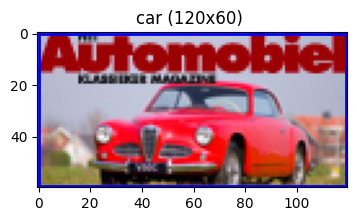

In [5]:
try:
    sample = IMDataset.load_image()
    plot_sample(sample[0], sample[1].astype(np.uint8))
except Exception as e:
    print(e)

In [6]:
try:
    dataset = IMDataset()
    print(len(dataset))
except Exception as e:
    print(e)

12295


In [7]:
class PipelinedDataset(IterableDataset):
    def __init__(self,
                 dir_dataset: Dataset,
                 process_sample: Callable[[Descriptor, np.ndarray], tuple[list[int], list[np.ndarray], Any]],
                 skip_factor=0.85
                 ):
        self.loader = DataLoader(dir_dataset, collate_fn=collate_fn)
        self.process_sample = process_sample
        self.skip_factor = skip_factor

    def __iter__(self):
        for descriptor, image in self.loader:
            labels, samples, *_ = self.process_sample(descriptor, image)
            for label, sample in zip(labels, samples):
                if label.argmax() == 4 and random.random() < self.skip_factor: continue
                yield sample / 255, label


In [12]:


try:
    dir_dataset = IMDataset()
    pipe_dataset = PipelinedDataset(dir_dataset, process_sample=IMDataset.process_sample)
    # count = 0
    # for _ in pipe_dataset: count += 1
    # print(count)
except:
    traceback.print_exc()


0.0 255.0


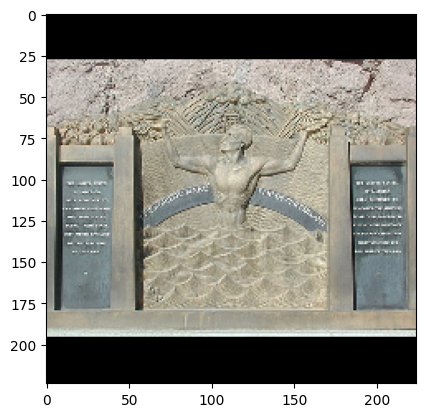

bus


In [13]:
try:
    sample = next(iter(pipe_dataset))
    print((sample[0] * 255).min(), (sample[0] * 255).max())
    plt.imshow((sample[0] * 255).astype(np.uint8))
    plt.show()
    print(idx_to_class[int(sample[1].argmax())])
except:
    traceback.print_exc()